In [41]:
import pandas as pd
import numpy as np
df=pd.read_csv(r'/content/Heart_failure (1).csv')
df

,Unnamed: 0,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,0,75.0,No,582,No,20,Yes,265000.00,1.9,130,Male,No,4,1
1,1,55.0,No,7861,No,38,No,263358.03,1.1,136,Male,No,6,1
2,2,65.0,No,146,No,20,No,162000.00,1.3,129,Male,Yes,7,1
3,3,50.0,Yes,111,No,20,No,210000.00,1.9,137,Male,No,7,1
4,4,65.0,Yes,160,Yes,20,No,327000.00,2.7,116,Female,No,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,294,62.0,No,61,Yes,38,Yes,155000.00,1.1,143,Male,Yes,270,0
295,295,55.0,No,1820,No,38,No,270000.00,1.2,139,Female,No,271,0
296,296,45.0,No,2060,Yes,60,No,742000.00,0.8,138,Female,No,278,0
297,297,45.0,No,2413,No,38,No,140000.00,1.4,140,Male,Yes,280,0


In [42]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [43]:
df.dtypes

,0
age,float64
anaemia,object
creatinine_phosphokinase,int64
diabetes,object
ejection_fraction,int64
high_blood_pressure,object
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,object


In [44]:
features=['anaemia','diabetes','high_blood_pressure','sex','smoking']
from sklearn.preprocessing import LabelEncoder,StandardScaler
encoders=[LabelEncoder() for i in features]

In [45]:
for i,col in enumerate(features):
  df[col]=encoders[i].fit_transform(df[col])

In [62]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [46]:
x=df.drop('DEATH_EVENT',axis=1)
y=df['DEATH_EVENT']

In [47]:
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.30,random_state=19)

In [48]:
from sklearn.naive_bayes import GaussianNB
bnb=GaussianNB()
bnb.fit(x_tr,y_tr)

GaussianNB()

In [49]:
y_pred=bnb.predict(x_te)

In [50]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score
print(classification_report(y_te,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88        65
           1       0.70      0.64      0.67        25

    accuracy                           0.82        90
   macro avg       0.78      0.77      0.77        90
weighted avg       0.82      0.82      0.82        90



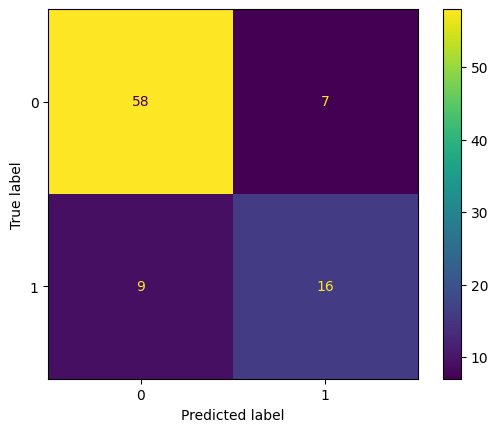

In [51]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred))

In [52]:
scale=StandardScaler()
x_tr_scaled=scale.fit_transform(x_tr)
x_te_scaled=scale.transform(x_te)

In [53]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_tr_scaled,y_tr)
y_pred_knn=knn.predict(x_te_scaled)

In [54]:
print(classification_report(y_te,y_pred_knn))

              precision    recall  f1-score   support

           0       0.76      0.94      0.84        65
           1       0.60      0.24      0.34        25

    accuracy                           0.74        90
   macro avg       0.68      0.59      0.59        90
weighted avg       0.72      0.74      0.70        90



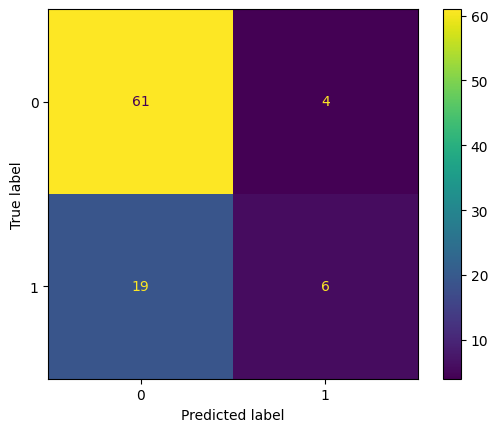

In [55]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred_knn))

In [56]:
from sklearn.naive_bayes import MultinomialNB
mnb=MultinomialNB()
mnb.fit(x_tr,y_tr)

MultinomialNB()

In [57]:
y_pred_mnb=mnb.predict(x_te)

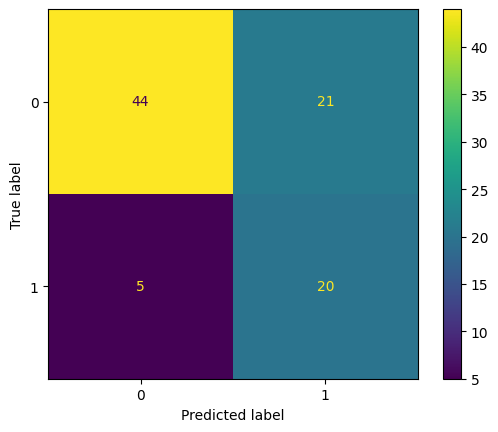

In [58]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred_mnb))

In [59]:
print(classification_report(y_te,y_pred_mnb))

              precision    recall  f1-score   support

           0       0.90      0.68      0.77        65
           1       0.49      0.80      0.61        25

    accuracy                           0.71        90
   macro avg       0.69      0.74      0.69        90
weighted avg       0.78      0.71      0.73        90



In [60]:
import pickle
pickle.dump(bnb,open('heartfail.sav','wb'))

In [61]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')